# 🛡️ Detección de fraude financiero
### 📊 Preprocesamiento y modelado predictivo

---

## 🌐 Visión general del proyecto

Este cuaderno representa la fase analítica y predictiva de nuestro sistema de detección de fraude. Partimos de un dataset maestro que ha sido previamente enriquecido utilizando **Neo4j** 🕸️ para extraer variables topológicas (como PageRank 📈 y grados históricos 🔗), calculadas de forma estricta mediante *Point-in-Time* ⏳ para evitar fugas de datos.

El reto fundamental de este proyecto es identificar transacciones ilícitas 🚨 en un ecosistema transaccional masivo y **extremadamente desbalanceado**, donde el fraude representa aproximadamente el 0.1% de las operaciones.

## 🔄 Flujo de trabajo 

El cuaderno está estructurado en las siguientes fases metodológicas:

* 🔍 **Análisis exploratorio y limpieza (EDA):** Evaluación de distribuciones, análisis de correlaciones 📊 y manejo consciente de valores atípicos (*outliers*), los cuales se mantienen intactos por su alto valor predictivo en el dominio financiero 💰.
* ⏳ **División temporal estricta:** Separación de los conjuntos de entrenamiento y prueba utilizando la variable temporal (`step >= 600` para test). Esto simula un entorno de producción real 🏭 y evita que el modelo sea evaluado con información del pasado.
* ⚙️ **Ingeniería de características:** Aplicación de *One-Hot Encoding* 🧩 para variables transaccionales y escalado de características (`StandardScaler`) 📏 ajustado únicamente en el conjunto de entrenamiento.

## 🤖 Estrategia de modelado algorítmico

Dado que los patrones de fraude son dinámicos 🔄, multivariantes 🕸️ y altamente no lineales 📉, hemos diseñado una fase de experimentación que evalúa y compara múltiples familias de algoritmos:

* 📘 **Modelos base lineales:** Naive Bayes y Regresión Logística, evaluados como *baselines* rápidos ⚡ y con alta interpretabilidad 🧠.
* 🌳 **Árbol de Decisión (Decision Tree):** Para capturar reglas lógicas iniciales y separaciones no lineales en los datos.
* 🌲 **Random Forest:** Un algoritmo de ensamblaje (*Bagging*) robusto 💪, ideal para reducir la varianza, evitar el sobreajuste y manejar la alta dimensionalidad.

> 🎯 **Objetivo final:** Construir un modelo capaz de maximizar la detección real del fraude (Recall/Precision) minimizando la fricción operativa para los usuarios legítimos.

In [1]:
import pandas as pd
import numpy as np
import math

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, OneHotEncoder

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

import seaborn as sns
import matplotlib.pyplot as plt

### 1. Carga del Dataset y Exploración Inicial

Comenzamos ingiriendo el dataset final enriquecido

El objetivo de este primer paso es cargar los datos, visualizar la estructura de la tabla y extraer estadísticas descriptivas. Esto nos permite observar la escala de las variables financieras y confirmar que las métricas extraídas del grafo (como PageRank y los grados históricos) se han cargado correctamente.

In [2]:
df = pd.read_csv('../data/processed/master_dataset_v3.csv.gz', compression='gzip')
df

,step,nameOrig,nameDest,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,in_degree_hist,out_degree_hist,orig_pagerank_hist,dest_pagerank_hist,same_louvain_community_hist
0,1,C1231006815,M1979787155,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,NaN,0,0,1.00,1.0000,0
1,1,C1666544295,M2044282225,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,NaN,0,0,1.00,1.0000,0
2,1,C1305486145,C553264065,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,NaN,0,0,1.00,1.0000,0
3,1,C840083671,C38997010,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,NaN,0,0,1.00,1.0000,0
4,1,C2048537720,M1230701703,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,NaN,0,0,1.00,1.0000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,C786484425,C776919290,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,NaN,1,0,0.15,0.2775,0
6362616,743,C1529008245,C1881841831,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,NaN,0,0,0.15,0.1500,0
6362617,743,C1162922333,C1365125890,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,NaN,2,0,0.15,0.4050,0
6362618,743,C1685995037,C2080388513,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,NaN,0,0,0.15,0.1500,0


In [3]:
df.shape

(6362620, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 16 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   step                         int64  
 1   nameOrig                     object 
 2   nameDest                     object 
 3   type                         object 
 4   amount                       float64
 5   oldbalanceOrg                float64
 6   newbalanceOrig               float64
 7   oldbalanceDest               float64
 8   newbalanceDest               float64
 9   isFraud                      int64  
 10  isFlaggedFraud               float64
 11  in_degree_hist               int64  
 12  out_degree_hist              int64  
 13  orig_pagerank_hist           float64
 14  dest_pagerank_hist           float64
 15  same_louvain_community_hist  int64  
dtypes: float64(8), int64(5), object(3)
memory usage: 776.7+ MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,in_degree_hist,out_degree_hist,orig_pagerank_hist,dest_pagerank_hist,same_louvain_community_hist
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,0.0,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6362620.0
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,NaN,5.027121e+00,1.458676e-03,2.268422e-01,7.814807e-01,0.0
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,NaN,7.819176e+00,3.822647e-02,2.440430e-01,9.444330e-01,0.0
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,1.500000e-01,1.500000e-01,0.0
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,1.500000e-01,1.500000e-01,0.0
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,NaN,1.000000e+00,0.000000e+00,1.500000e-01,4.050000e-01,0.0
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,NaN,7.000000e+00,0.000000e+00,1.500000e-01,1.000000e+00,0.0
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,NaN,1.120000e+02,2.000000e+00,7.417500e+00,1.417500e+01,0.0


### 2. Selección de Características y Reducción de Dimensionalidad

No todas las columnas originales son útiles o seguras para el entrenamiento de un modelo de Machine Learning. En esta fase procedemos a eliminar:
* **`nameOrig` y `nameDest`**: Son identificadores únicos. Incluirlos generaría un sobreajuste masivo, ya que el modelo intentaría memorizar cuentas individuales en lugar de aprender patrones de comportamiento.
* **`isFlaggedFraud`**: Es una marca heurística del sistema original, no una característica transaccional.
* **`same_louvain_community_hist`**: El análisis exploratorio previo reveló que esta variable presenta una varianza nula (todos los valores son 0) para nuestra configuración temporal, por lo que no aporta señal predictiva y debe ser descartada.

In [6]:
columnas_a_eliminar = [
    'nameDest',
    'nameOrig',
    'isFlaggedFraud',
    'same_louvain_community_hist',
]

df.drop(columns=columnas_a_eliminar, inplace=True)

In [7]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,in_degree_hist,out_degree_hist,orig_pagerank_hist,dest_pagerank_hist
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0,0,1.00,1.0000
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0,0,1.00,1.0000
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0,0,1.00,1.0000
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0,0,1.00,1.0000
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0,0,1.00,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,1,0,0.15,0.2775
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0,0,0.15,0.1500
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,2,0,0.15,0.4050
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0,0,0.15,0.1500


### 3. Estandarización de Nomenclatura (Snake Case)

Para garantizar consistencia y facilitar el manejo de las variables mediante notación de punto en `pandas`, aplicamos buenas prácticas de ingeniería de datos estandarizando los nombres de las columnas al formato `snake_case`. Esto limpia la sintaxis y previene errores tipográficos en la fase de modelado.

In [8]:
nuevos_nombres = {
    'oldbalanceOrg': 'old_balance_orig',
    'newbalanceOrig': 'new_balance_orig',
    'oldbalanceDest': 'old_balance_dest',
    'newbalanceDest': 'new_balance_dest',
    'isFraud': 'is_fraud',
}

df.rename(columns=nuevos_nombres, inplace=True)

print("✅ Columnas renombradas correctamente:")
print(df.columns.tolist())

✅ Columnas renombradas correctamente:
['step', 'type', 'amount', 'old_balance_orig', 'new_balance_orig', 'old_balance_dest', 'new_balance_dest', 'is_fraud', 'in_degree_hist', 'out_degree_hist', 'orig_pagerank_hist', 'dest_pagerank_hist']


## 4. Calidad de Datos

Antes de avanzar a la exploración visual y al entrenamiento, validamos la integridad estructural de la matriz de datos:

### 4.1. Valores nulos 

Comprobamos que no existen campos vacíos, lo que nos evita tener que introducir sesgos mediante técnicas de imputación sintética.

In [9]:
print(df.isna().sum())

step                  0
type                  0
amount                0
old_balance_orig      0
new_balance_orig      0
old_balance_dest      0
new_balance_dest      0
is_fraud              0
in_degree_hist        0
out_degree_hist       0
orig_pagerank_hist    0
dest_pagerank_hist    0
dtype: int64


### 4.2. Valores únicos 

Nos aseguramos de que las variables categóricas (como `type`) no contengan valores inesperados o inconsistentes que puedan confundir al modelo.

In [10]:
print(df['type'].unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


### 4.3. Duplicados

Detectamos registros que son réplicas exactas. Al tratarse de una cantidad residual (alrededor de 500 filas sobre un total de más de 6.3 millones), procedemos a eliminarlos para mantener la máxima pureza analítica sin afectar la representatividad estadística del conjunto.

In [11]:
print("Filas duplicadas:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 534
Filas duplicadas: 0


## 5. Análisis Exploratorio Visual (EDA)

### 5.1. Análisis de Correlación Lineal con la Variable Objetivo

Comenzamos evaluando la correlación lineal (coeficiente de Pearson) entre nuestras características numéricas y la variable objetivo (`is_fraud`). 

Como se puede observar en los resultados, **ninguna variable presenta una fuerte correlación lineal directa**. Las variables con mayor peso relativo son `amount` y `step`, pero sus valores siguen siendo muy cercanos a 0.

In [12]:
correlaciones = df.select_dtypes(include=["float64", "int64"]).corr()['is_fraud'].drop('is_fraud')
print(correlaciones)

step                  0.031534
amount                0.076169
old_balance_orig      0.010048
new_balance_orig     -0.008143
old_balance_dest     -0.005878
new_balance_dest      0.000451
in_degree_hist       -0.010742
out_degree_hist       0.000691
orig_pagerank_hist   -0.007181
dest_pagerank_hist   -0.010590
Name: is_fraud, dtype: float64


### 5.2. Distribución de la Operativa por Tipo de Transacción

Para entender el contexto de negocio, visualizamos el volumen de operaciones según su naturaleza. El ecosistema de pagos está compuesto por distintas operativas (pagos, transferencias, retiros, etc.).

Conocer la distribución "normal" del sistema es vital. En este dataset, sabemos por la naturaleza del problema que los estafadores suelen utilizar mecánicas muy específicas para extraer los fondos (típicamente `TRANSFER` seguidas de `CASH_OUT`). Identificar el peso de estas categorías sobre el total nos ayudará a entender dónde debe enfocar el modelo su mayor capacidad predictiva.

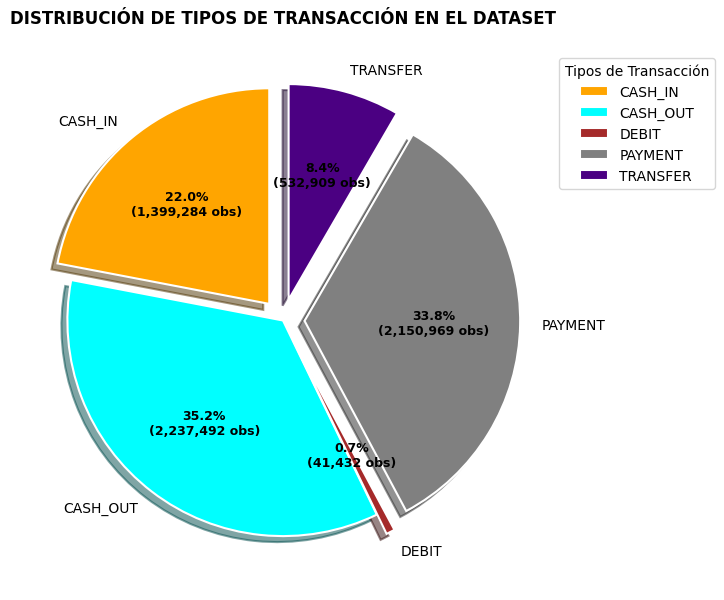

In [13]:
df_gb = df.groupby(['type']).size()
tipos = df_gb.index.values

explode = (0.1, 0.0, 0.1, 0.1, 0.1)
colors = ("orange", "cyan", "brown", "grey", "indigo")
wp = {'linewidth': 1.5, 'edgecolor': "white"}

def func(pct, allvalues):
    absolute = int(round(pct / 100. * np.sum(allvalues)))
    return f"{pct:.1f}%\n({absolute:,} obs)"

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)

wedges, texts, autotexts = ax.pie(
    df_gb, 
    autopct=lambda pct: func(pct, df_gb),
    explode=explode, 
    labels=tipos, 
    shadow=True, 
    colors=colors,
    startangle=90, 
    wedgeprops=wp, 
    textprops=dict(color="black")
)

ax.legend(
    wedges, tipos,
    title="Tipos de Transacción",
    loc="upper left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.setp(autotexts, size=9, weight="bold")
ax.set_title("DISTRIBUCIÓN DE TIPOS DE TRANSACCIÓN EN EL DATASET", pad=20, weight="bold")

plt.show()

### 5.3. El Desbalanceo de Clases: El Reto Principal

En este paso visualizamos el mayor desafío técnico de cualquier sistema de detección de fraude real: **el desbalanceo extremo de las clases**.

Como muestra el gráfico, el fraude representa apenas un **0.1%** del total de transacciones.<br/>
**Métricas de Evaluación:** La métrica de exactitud (*Accuracy*) queda totalmente invalidada (un modelo que prediga que "nada es fraude" tendría un 99.9% de exactitud, pero sería inútil). Deberemos centrarnos en métricas como **Precision, Recall, F1-Score y el área bajo la curva Precision-Recall (PR-AUC)**.

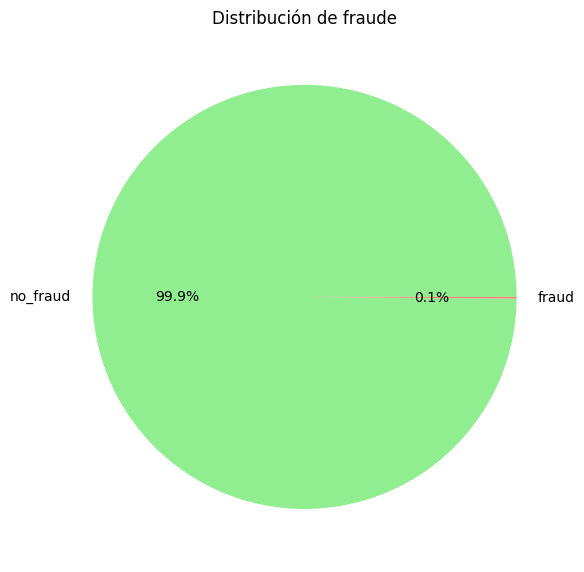

In [14]:
plt.figure(figsize=(6, 6))
df['is_fraud'].map({0: 'no_fraud', 1: 'fraud'}).value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
plt.title('Distribución de fraude')
plt.ylabel("")
plt.tight_layout()
plt.show()

### 5.4. Análisis de Valores Atípicos (Outliers)

Exploramos la dispersión de los datos mediante diagramas de caja (*Boxplots*) y el método del Rango Intercuartílico (IQR) para cuantificar los valores atípicos de las variables financieras y estructurales del grafo.

**Decisión metodológica clave:** Aunque el sistema detecta cientos de miles de registros como *outliers* estadísticos, **se ha decidido conservarlos todos sin aplicar técnicas de truncamiento (*clipping*) o eliminación**. 
* Una transferencia de una cantidad extraordinaria o un pico repentino de conexiones en la red (grados en el grafo) no representan necesariamente "errores de medición", sino la realidad operativa de cuentas de alto patrimonio corporativo o, precisamente, un ataque coordinado de fraude. Eliminar los extremos de las distribuciones significaría destruir las señales de alarma más valiosas para el modelo.

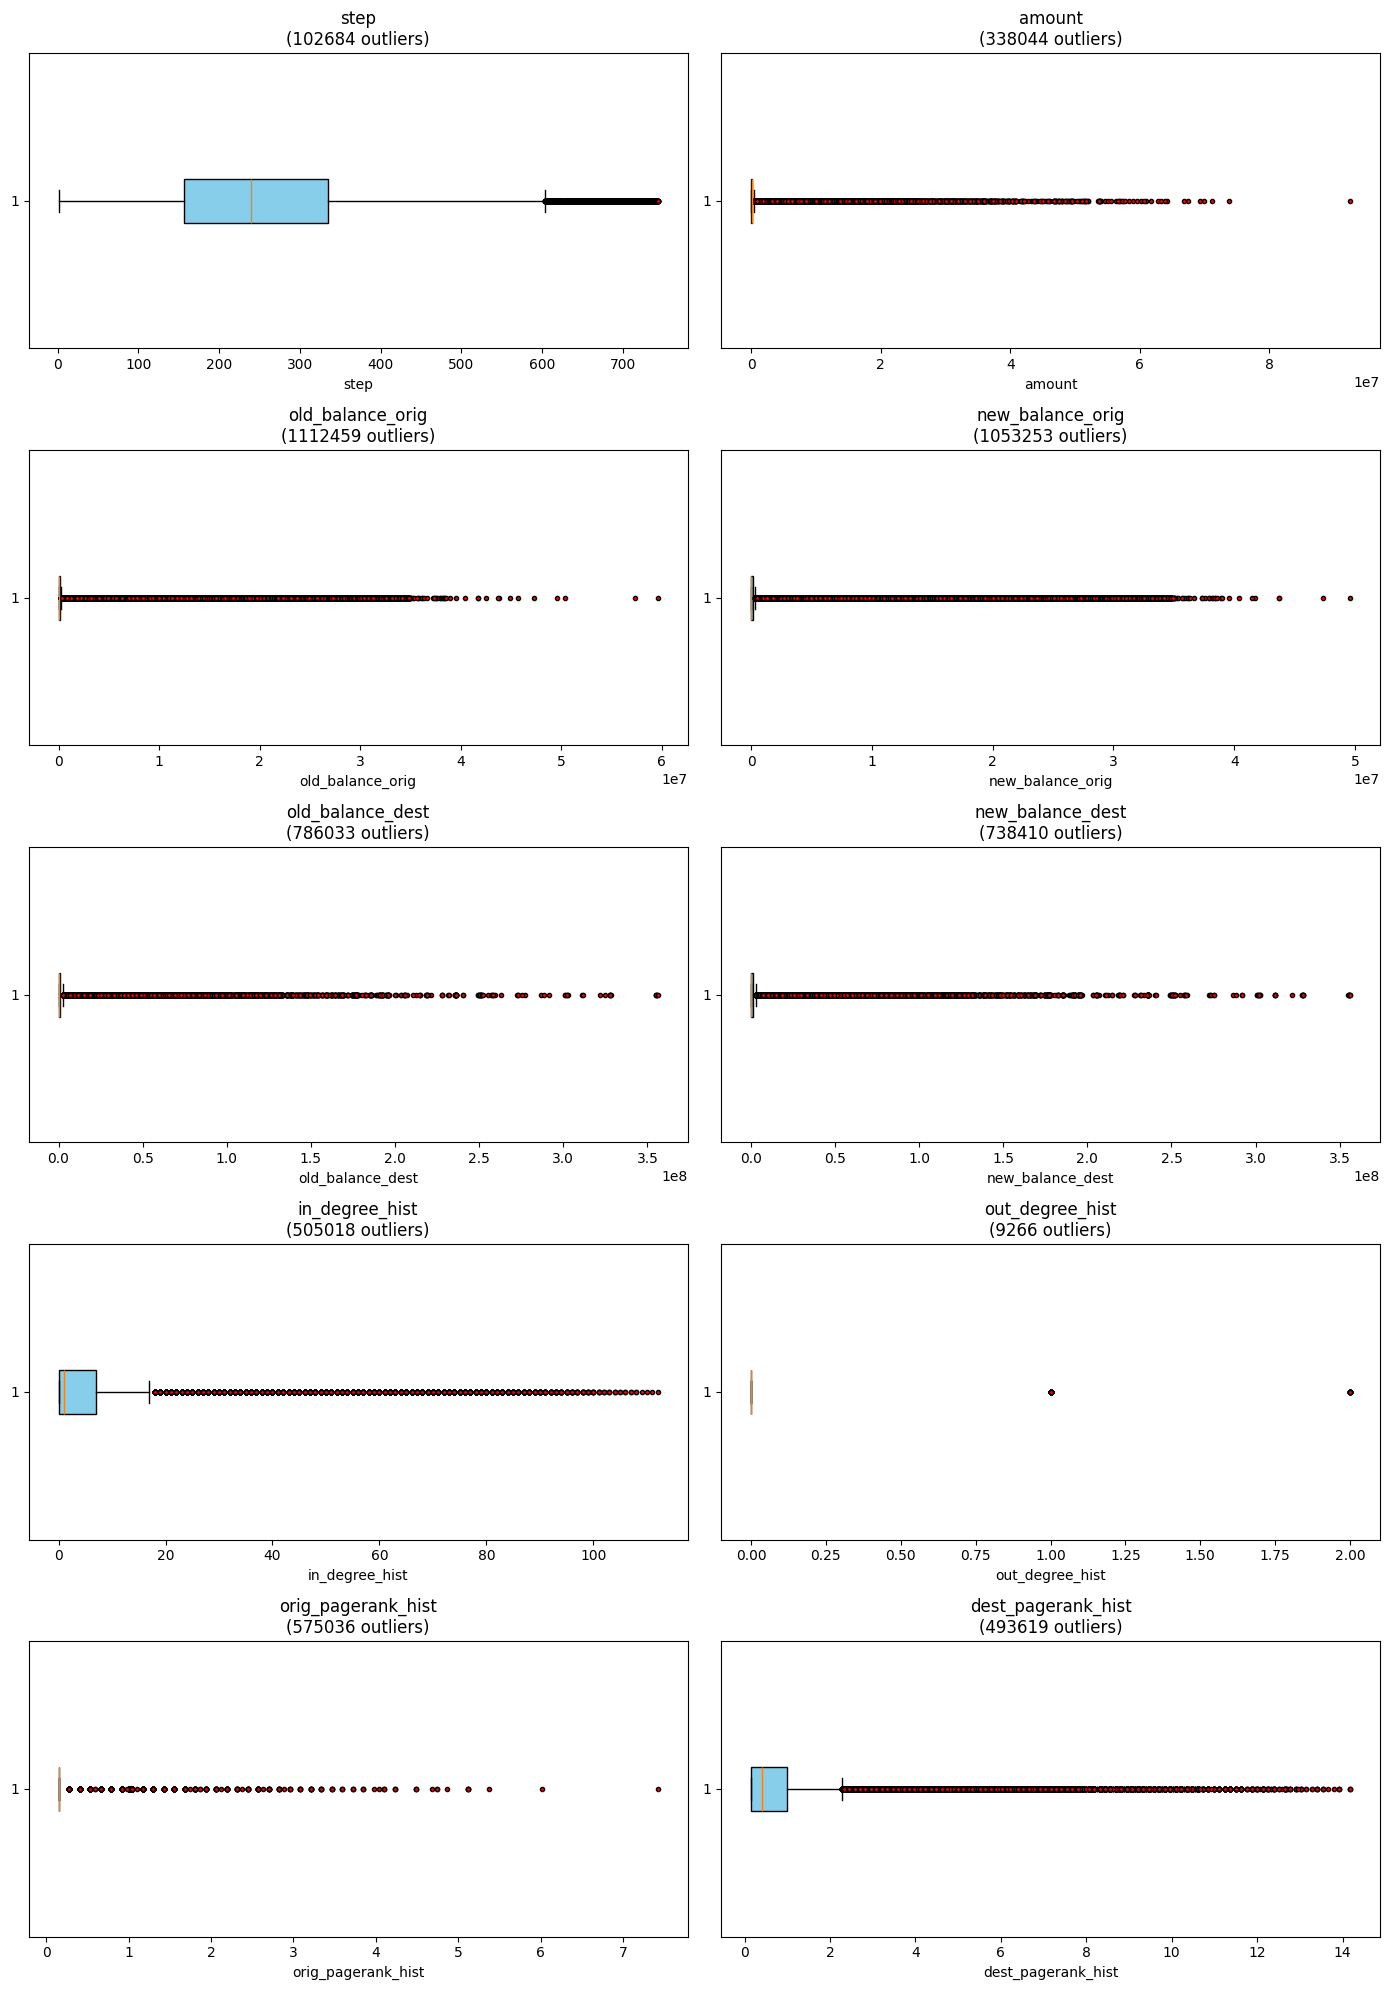

In [15]:
columnas_numericas = df.select_dtypes(include=["float64", "int64"]).columns.drop(["is_fraud"])

n_cols_plot = 2
n_rows_plot = math.ceil(len(columnas_numericas) / n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(14, n_rows_plot * 4))
axes = axes.flatten()

outliers_info = {}

for i, col in enumerate(columnas_numericas):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    n_outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)].shape[0]
    outliers_info[col] = n_outliers

    axes[i].boxplot(df[col], vert=False, patch_artist=True, 
                    boxprops=dict(facecolor="skyblue"),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=3))
    
    axes[i].set_title(f"{col}\n({n_outliers} outliers)", fontsize=12)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("outliers_boxplot.png")
plt.show()

In [16]:

print("Resumen de outliers detectados:", outliers_info)

Resumen de outliers detectados: {'step': 102684, 'amount': 338044, 'old_balance_orig': 1112459, 'new_balance_orig': 1053253, 'old_balance_dest': 786033, 'new_balance_dest': 738410, 'in_degree_hist': 505018, 'out_degree_hist': 9266, 'orig_pagerank_hist': 575036, 'dest_pagerank_hist': 493619}


## 6. División del Dataset (Train/Test Split Temporal)

En problemas financieros y de detección de fraude, el tiempo es una variable crítica. Si dividiéramos los datos de forma aleatoria, cometeríamos el error de entrenar al modelo con información futura para predecir eventos pasados, lo que inflaría artificialmente su rendimiento (fuga de datos o *data leakage*).

Para garantizar una evaluación realista, realizamos una **división temporal estricta**:
* **Entrenamiento (Train):** Todas las transacciones ocurridas antes del paso temporal 600 (`step < 600`).
* **Prueba (Test):** Las transacciones ocurridas a partir del paso temporal 600 (`step >= 600`), que simularán los datos "nuevos" en producción.

Tras la división, eliminamos la variable `step` (ya que ha cumplido su propósito de ordenación) y separamos nuestra variable objetivo (`is_fraud`).

In [17]:
train_df = df[df['step'] < 600].copy()
test_df = df[df['step'] >= 600].copy()

X_train = train_df.drop(columns=['is_fraud', 'step'])
y_train = train_df['is_fraud']

X_test = test_df.drop(columns=['is_fraud', 'step'])
y_test = test_df['is_fraud']

## 7. Codificación de Variables Categóricas (One-Hot Encoding)

Los algoritmos de Machine Learning requieren entradas numéricas. Nuestra única variable categórica es el tipo de transacción (`type`). 

Para transformarla, aplicamos **One-Hot Encoding**, creando una columna binaria por cada tipo de transacción.

In [18]:

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

train_types = encoder.fit_transform(X_train[['type']])
test_types = encoder.transform(X_test[['type']])

train_types_df = pd.DataFrame(train_types, columns=encoder.get_feature_names_out(['type']), index=X_train.index)
test_types_df = pd.DataFrame(test_types, columns=encoder.get_feature_names_out(['type']), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=['type']), train_types_df], axis=1)
X_test = pd.concat([X_test.drop(columns=['type']), test_types_df], axis=1)

## 8. Escalado y Normalización de Características

Las variables financieras y estructurales de nuestro dataset operan en magnitudes completamente diferentes (por ejemplo, el PageRank tiene valores decimales pequeños, mientras que los montos de transferencia pueden ser de millones). Para que los algoritmos no den más importancia a una variable simplemente por su escala matemática, estandarizamos los datos.

Utilizamos `StandardScaler` para que todas las características tengan una media de **0** y una desviación estándar de **1**. 
* **Prevención de fuga de datos:** El escalador se ajusta (`fit`) **únicamente con los datos de entrenamiento**. Posteriormente, aplicamos esa misma transformación (`transform`) a los datos de prueba. Esto garantiza que la información del conjunto de test no contamine los parámetros de escalado.

In [19]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 9. Entrenamiento y Validación de Modelos Predictivos

En esta fase central del proyecto, procedemos a entrenar y evaluar iterativamente distintas familias de algoritmos de Machine Learning. El objetivo es encontrar el modelo que mejor logre identificar los patrones complejos y dinámicos del fraude, lidiando eficazmente con el desbalanceo extremo del dataset.

Para cada algoritmo, analizaremos métricas críticas en el dominio financiero, priorizando el **PR-AUC** (Área bajo la curva Precision-Recall), el **Recall** (capacidad de atrapar el fraude real) y la **Especificidad** (minimización de falsas alarmas que bloqueen a clientes legítimos).

## 📊 Guía de Métricas: Evaluación de Fraude Bancario

En la detección de fraudes, la **Exactitud (Accuracy)** es una métrica tramposa.  
Si la inmensa mayoría de las transacciones son legítimas, un modelo flojo que apruebe absolutamente todo tendrá una exactitud cercana al 100%, pero el banco perderá todo el dinero de los robos.

Por ello, evaluamos el impacto real utilizando este ecosistema de métricas específicas:

---

### 📈 1. Precisión (Fiabilidad de la Alerta)

**¿Qué es?**  
Mide la efectividad de la alarma cuando salta. Responde a la pregunta:  
> De todas las transacciones que el modelo bloqueó asegurando que eran fraude, ¿cuántas lo eran realmente?

**Impacto en el negocio:**  
Si la precisión es baja, el modelo genera demasiadas falsas alarmas, lo que satura al equipo de soporte operativo atendiendo reclamos innecesarios.

---

### 🎯 2. Recall / Sensibilidad (Fraudes Atrapados)

**¿Qué es?**  
Mide el tamaño de la red de arrastre del modelo. Responde a la pregunta:  
> De todos los fraudes reales que intentaron atacar al banco, ¿qué porcentaje logramos interceptar?

**Impacto en el negocio:**  
Si el Recall es bajo, el modelo es "ciego" ante estafadores astutos y el banco pierde dinero directamente al tener que asumir el costo del dinero robado.

---

### 🥇 3. PR-AUC (La Métrica Reina)

**¿Qué es?**  
Evalúa la capacidad global del modelo para separar el fraude de las compras normales. Lo hace analizando el comportamiento de la Precisión y el Recall a través de todos los niveles de sospecha posibles (umbrales).

**Impacto en el negocio:**  
Al ignorar la masa gigante de transacciones legítimas y enfocarse solo en la clase minoritaria (el fraude), un valor cercano a 1.0 le garantiza al equipo de datos que el modelo es matemáticamente robusto y no está adivinando por suerte.

---

### 🛡️ 4. Especificidad (Protección al Cliente Bueno)

**¿Qué es?**  
Mide la salud de la experiencia de usuario de la gran mayoría. Responde a la pregunta:  
> De todas las personas que usaron su tarjeta de forma totalmente legal, ¿a qué porcentaje se le permitió operar sin molestias ni bloqueos erróneos?

**Impacto en el negocio:**  
Una baja especificidad significa que el modelo es paranoico y congela las cuentas de clientes inocentes en su día a día, destruyendo la confianza en el banco.

### 9.1. Modelo Baseline: Gaussian Naive Bayes

Comenzamos nuestra experimentación con **Gaussian Naive Bayes**, un algoritmo probabilístico basado en el Teorema de Bayes. 

Lo utilizamos como nuestro primer *baseline* (modelo base de referencia) debido a su extrema rapidez de entrenamiento. Es importante tener en cuenta que este algoritmo asume una fuerte independencia entre las variables (algo poco común en fraudes complejos) y supone que los datos continuos siguen una distribución normal (Gaussiana). 

Dado que nuestro análisis exploratorio (EDA) confirmó la presencia de fuertes asimetrías y *outliers* naturales en las transferencias financieras, no esperamos que este modelo sea el definitivo, pero nos dará un suelo de rendimiento (especialmente en la métrica PR-AUC) que los modelos más complejos deberán superar.

⏳ Iniciando el experimento con Gaussian Naive Bayes...
🏋️ Entrenando el modelo en el set de Train (Steps <= 600)...
🔮 Generando predicciones en el set de Test (Steps > 600)...
✅ Predicciones completadas. Calculando métricas...
------------------------------------------------------------

🏆 === REPORTE DE RENDIMIENTO: GAUSSIAN NAIVE BAYES ===
🥇 MÉTRICA REINA (PR-AUC): 0.1951
🎯 RECALL (Fraudes Atrapados): 0.9969 -> (99.69% del total real)
🛡️ ESPECIFICIDAD (Falsas Alarmas): 0.5903 -> (Bloqueó al 40.97% de clientes buenos)
⚖️ F1-SCORE (Balance General): 0.0715
📈 PRECISIÓN (Efectividad Alerta): 0.0371
------------------------------------------------------------

📋 INFORME DETALLADO DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Legítimo       1.00      0.59      0.74    101973
      Fraude       0.04      1.00      0.07      1614

    accuracy                           0.60    103587
   macro avg       0.52      0.79      0.41    103587
weighted avg       0.98 

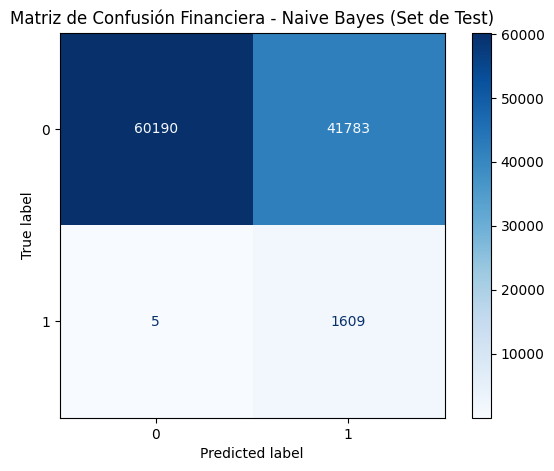

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ( ConfusionMatrixDisplay, classification_report, average_precision_score, recall_score, precision_score, f1_score)

print("⏳ Iniciando el experimento con Gaussian Naive Bayes...")

clasificador_NB = GaussianNB()

print("🏋️ Entrenando el modelo en el set de Train (Steps <= 600)...")
clasificador_NB.fit(X_train_final, y_train)

print("🔮 Generando predicciones en el set de Test (Steps > 600)...")
predicciones_NB = clasificador_NB.predict(X_test_final)
probabilidades_NB = clasificador_NB.predict_proba(X_test_final)[:,1]

print("✅ Predicciones completadas. Calculando métricas...")
print("-"*60)

precision_NB = precision_score(y_test, predicciones_NB)
recall_NB = recall_score(y_test, predicciones_NB)
f1_NB = f1_score(y_test, predicciones_NB)

pr_auc_NB = average_precision_score(y_test, probabilidades_NB)

especificidad_NB = recall_score(y_test, predicciones_NB, pos_label=0)

print("\n🏆 === REPORTE DE RENDIMIENTO: GAUSSIAN NAIVE BAYES ===")
print(f"🥇 MÉTRICA REINA (PR-AUC): {pr_auc_NB:.4f}")
print(f"🎯 RECALL (Fraudes Atrapados): {recall_NB:.4f} -> ({round(recall_NB*100,2)}% del total real)")
print(f"🛡️ ESPECIFICIDAD (Falsas Alarmas): {especificidad_NB:.4f} -> (Bloqueó al {round((1-especificidad_NB)*100,2)}% de clientes buenos)")
print(f"⚖️ F1-SCORE (Balance General): {f1_NB:.4f}")
print(f"📈 PRECISIÓN (Efectividad Alerta): {precision_NB:.4f}")
print("-"*60)

print("\n📋 INFORME DETALLADO DE CLASIFICACIÓN:")
print(classification_report(y_test, predicciones_NB, target_names=['Legítimo','Fraude']))
print("-"*60)

fig, ax = plt.subplots(figsize=(7,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_NB,
    ax=ax,
    cmap='Blues',
    values_format='d'
)

plt.title('Matriz de Confusión Financiera - Naive Bayes (Set de Test)')
plt.grid(False)
plt.show()

## 9.2. Regresión Logística (Logistic Regression)

Continuamos la fase de experimentación utilizando Regresión Logística. A diferencia de Naive Bayes, este algoritmo es un modelo lineal que no asume la independencia absoluta de las variables, sino que asigna un peso o coeficiente óptimo a cada característica mediante la maximización de la función de verosimilitud.

Debido a que su motor matemático se basa en la optimización por gradiente descendente, este algoritmo requiere estrictamente el uso de los datos escalados y normalizados (`X_train_final` y `X_test_final`). De lo contrario, las variables financieras con rangos numéricos masivos (como los montos de las transacciones) sesgarían los coeficientes e impedirían la convergencia del modelo.

Este paso nos servirá para establecer un límite de rendimiento lineal sólido antes de dar el salto a los algoritmos basados en estructuras de árboles.

⏳ Iniciando el experimento con Regresión Logística...
🏋️ Entrenando el modelo en el set de Train (Steps <= 600)...
🔮 Generando predicciones en el set de Test (Steps > 600)...
✅ Predicciones completadas. Calculando métricas...
------------------------------------------------------------

🏆 === REPORTE DE RENDIMIENTO: REGRESIÓN LOGÍSTICA ===
🥇 MÉTRICA REINA (PR-AUC): 0.7329
🎯 RECALL (Fraudes Atrapados): 0.3587 -> (35.87% del total real)
🛡️ ESPECIFICIDAD (Falsas Alarmas): 1.0000 -> (Bloqueó al 0.0% de clientes buenos)
⚖️ F1-SCORE (Balance General): 0.5276
📈 PRECISIÓN (Efectividad Alerta): 0.9966
------------------------------------------------------------

📋 INFORME DETALLADO DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Legítimo       0.99      1.00      0.99    101973
      Fraude       1.00      0.36      0.53      1614

    accuracy                           0.99    103587
   macro avg       0.99      0.68      0.76    103587
weighted avg       0.99     

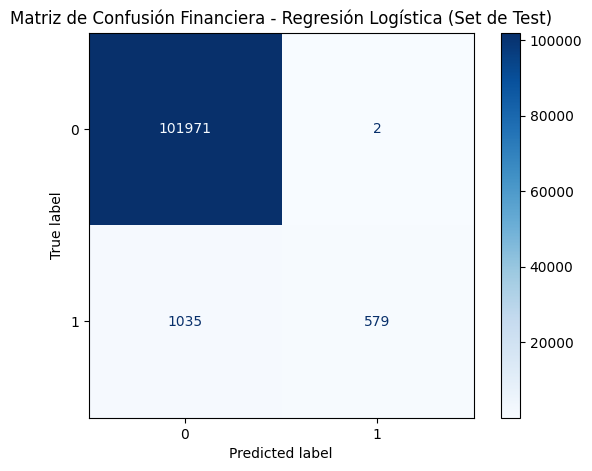

In [21]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, average_precision_score, recall_score, precision_score, f1_score)

print("⏳ Iniciando el experimento con Regresión Logística...")

clasificador_lr = LogisticRegression(max_iter=1000, random_state=42)

print("🏋️ Entrenando el modelo en el set de Train (Steps <= 600)...")
clasificador_lr.fit(X_train_final, y_train)

print("🔮 Generando predicciones en el set de Test (Steps > 600)...")
predicciones_lr = clasificador_lr.predict(X_test_final)
probabilidades_lr = clasificador_lr.predict_proba(X_test_final)[:,1]

print("✅ Predicciones completadas. Calculando métricas...")
print("-"*60)

precision_lr = precision_score(y_test, predicciones_lr)
recall_lr = recall_score(y_test, predicciones_lr)
f1_lr = f1_score(y_test, predicciones_lr)

pr_auc_lr = average_precision_score(y_test, probabilidades_lr)

especificidad_lr = recall_score(y_test, predicciones_lr, pos_label=0)

print("\n🏆 === REPORTE DE RENDIMIENTO: REGRESIÓN LOGÍSTICA ===")
print(f"🥇 MÉTRICA REINA (PR-AUC): {pr_auc_lr:.4f}")
print(f"🎯 RECALL (Fraudes Atrapados): {recall_lr:.4f} -> ({round(recall_lr*100,2)}% del total real)")
print(f"🛡️ ESPECIFICIDAD (Falsas Alarmas): {especificidad_lr:.4f} -> (Bloqueó al {round((1-especificidad_lr)*100,2)}% de clientes buenos)")
print(f"⚖️ F1-SCORE (Balance General): {f1_lr:.4f}")
print(f"📈 PRECISIÓN (Efectividad Alerta): {precision_lr:.4f}")
print("-"*60)

print("\n📋 INFORME DETALLADO DE CLASIFICACIÓN:")
print(classification_report(y_test, predicciones_lr, target_names=['Legítimo','Fraude']))
print("-"*60)

fig, ax = plt.subplots(figsize=(7,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_lr,
    ax=ax,
    cmap='Blues',
    values_format='d'
)

plt.title('Matriz de Confusión Financiera - Regresión Logística (Set de Test)')
plt.grid(False)
plt.show()

## 9.3. Árbol de Decisión (Decision Tree)

Damos el salto hacia los modelos no lineales utilizando un Árbol de Decisión. Este algoritmo divide el espacio de características de forma jerárquica mediante reglas lógicas ortogonales, lo que permite capturar interacciones complejas entre variables que los modelos lineales pasan por alto.

En este bloque aplicamos dos configuraciones estratégicas fundamentales para nuestro escenario de negocio:

- **Invarianza de escala:**  
  Al basarse en umbrales lógicos individuales, los árboles no se ven afectados por las magnitudes de las variables. Por ello, entrenamos directamente con los datos puros codificados sin escalar (`X_train` y `X_test`). Esto mantiene la interpretabilidad del modelo intacta.

- **Control de sobreajuste e hiperparámetros:**  
  Limitamos la profundidad máxima mediante `max_depth=10` para evitar que el árbol memorice el ruido de los 6.3 millones de registros. Además, incorporamos `class_weight='balanced'`, lo que obliga al algoritmo a penalizar con mayor severidad los errores sobre la clase fraudulenta, compensando activamente el fuerte desbalanceo del dataset (~0.1%).

⏳ Iniciando el experimento con Árbol de Decisión...
🏋️ Entrenando el Árbol de Decisión en el set de Train (Datos sin escalar)...
🔮 Generando predicciones en el set de Test (Datos sin escalar)...
✅ Predicciones completadas. Calculando métricas...
------------------------------------------------------------

🏆 === REPORTE DE RENDIMIENTO: ÁRBOL DE DECISIÓN ===
🥇 MÉTRICA REINA (PR-AUC): 0.9581
🎯 RECALL (Fraudes Atrapados): 0.9913 -> (99.13% del total real)
🛡️ ESPECIFICIDAD (Falsas Alarmas): 0.9933 -> (Bloqueó al 0.67% de clientes buenos)
⚖️ F1-SCORE (Balance General): 0.8211
📈 PRECISIÓN (Efectividad Alerta): 0.7008
------------------------------------------------------------

📋 INFORME DETALLADO DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Legítimo       1.00      0.99      1.00    101973
      Fraude       0.70      0.99      0.82      1614

    accuracy                           0.99    103587
   macro avg       0.85      0.99      0.91    103587
weighted 

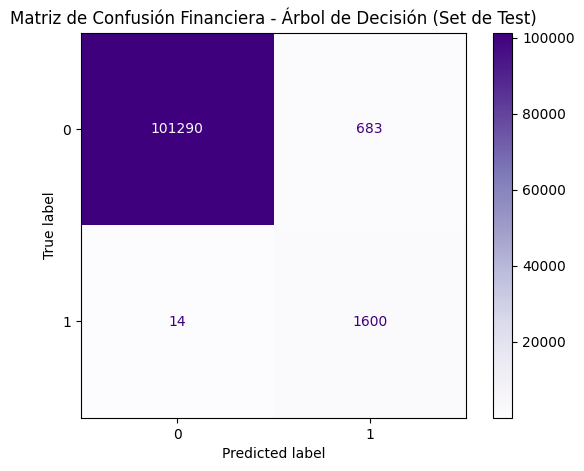

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, 
    classification_report, 
    average_precision_score, 
    recall_score, 
    precision_score, 
    f1_score
)

print("⏳ Iniciando el experimento con Árbol de Decisión...")

modelo_dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)

print("🏋️ Entrenando el Árbol de Decisión en el set de Train (Datos sin escalar)...")
modelo_dt.fit(X_train, y_train)

print("🔮 Generando predicciones en el set de Test (Datos sin escalar)...")
predicciones_dt = modelo_dt.predict(X_test)
probabilidades_dt = modelo_dt.predict_proba(X_test)[:, 1]

print("✅ Predicciones completadas. Calculando métricas...")
print("-" * 60)

precision_dt = precision_score(y_test, predicciones_dt)
recall_dt = recall_score(y_test, predicciones_dt)
f1_dt = f1_score(y_test, predicciones_dt)
pr_auc_dt = average_precision_score(y_test, probabilidades_dt)
especificidad_dt = recall_score(y_test, predicciones_dt, pos_label=0)

print("\n🏆 === REPORTE DE RENDIMIENTO: ÁRBOL DE DECISIÓN ===")
print(f"🥇 MÉTRICA REINA (PR-AUC): {pr_auc_dt:.4f}")
print(f"🎯 RECALL (Fraudes Atrapados): {recall_dt:.4f} -> ({round(recall_dt*100,2)}% del total real)")
print(f"🛡️ ESPECIFICIDAD (Falsas Alarmas): {especificidad_dt:.4f} -> (Bloqueó al {round((1-especificidad_dt)*100,2)}% de clientes buenos)")
print(f"⚖️ F1-SCORE (Balance General): {f1_dt:.4f}")
print(f"📈 PRECISIÓN (Efectividad Alerta): {precision_dt:.4f}")
print("-" * 60)

print("\n📋 INFORME DETALLADO DE CLASIFICACIÓN:")
print(classification_report(y_test, predicciones_dt, target_names=['Legítimo', 'Fraude']))
print("-" * 60)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    predicciones_dt, 
    ax=ax, 
    cmap='Purples', 
    values_format='d'
)

plt.title('Matriz de Confusión Financiera - Árbol de Decisión (Set de Test)')
plt.grid(False)
plt.show()

## 9.4. Random Forest (Bosque Aleatorio)

Evolucionamos nuestra estrategia de modelado hacia los algoritmos de ensamble utilizando Random Forest. Este modelo funciona bajo el principio de *Bagging* (*Bootstrap Aggregating*), construyendo múltiples árboles de decisión de forma paralela e independiente sobre diferentes subconjuntos de datos y características, para luego combinar sus predicciones mediante voto mayoritario.

Esta técnica aporta ventajas críticas para nuestro pipeline:

- **Reducción de varianza:**  
  Al combinar las predicciones de múltiples árboles independientes, mitigamos drásticamente el riesgo de sobreajuste (*overfitting*) observado en un árbol único, mejorando la capacidad de generalización sobre datos futuros.

- **Operación sin escalado:**  
  Al estar compuesto íntegramente por árboles de decisión, el modelo mantiene la invarianza a la escala. Por ello, entrenamos directamente con los datos puros (`X_train` y `X_test`).

- **Configuración de eficiencia:**  
  Ajustamos el modelo a `n_estimators=50` con una profundidad máxima de `max_depth=12` para lograr un equilibrio óptimo entre potencia predictiva y consumo de recursos sobre los 6.3 millones de registros. Además, utilizamos `class_weight='balanced'` para compensar activamente el fuerte desbalanceo de clases y `n_jobs=-1` para paralelizar el entrenamiento utilizando todos los núcleos disponibles del procesador.

⏳ Iniciando el experimento con Random Forest...
🏋️ Entrenando el Bosque Aleatorio en el set de Train (Datos sin escalar)...
⏱️ Entrenamiento completado en 3.81 minutos.
🔮 Generando predicciones en el set de Test (Datos sin escalar)...
✅ Predicciones completadas. Calculando métricas...
------------------------------------------------------------

🏆 === REPORTE DE RENDIMIENTO: RANDOM FOREST ===
🥇 MÉTRICA REINA (PR-AUC): 0.9430
🎯 RECALL (Fraudes Atrapados): 0.9932 -> (99.32% del total real)
🛡️ ESPECIFICIDAD (Falsas Alarmas): 0.9745 -> (Bloqueó al 2.55% de clientes buenos)
⚖️ F1-SCORE (Balance General): 0.5513
📈 PRECISIÓN (Efectividad Alerta): 0.3816
------------------------------------------------------------

📋 INFORME DETALLADO DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Legítimo       1.00      0.97      0.99    101973
      Fraude       0.38      0.99      0.55      1614

    accuracy                           0.97    103587
   macro avg       0.69    

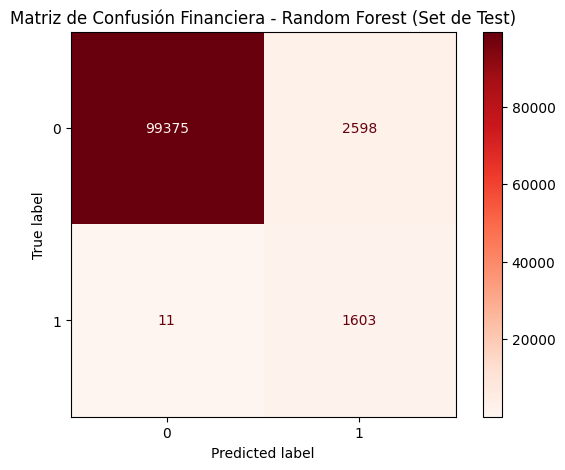

In [22]:
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, average_precision_score, recall_score, precision_score, f1_score)

print("⏳ Iniciando el experimento con Random Forest...")

modelo_rf = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=1
)

print("🏋️ Entrenando el Bosque Aleatorio en el set de Train (Datos sin escalar)...")
start_time = time.time()
modelo_rf.fit(X_train, y_train)
end_time = time.time()

print(f"⏱️ Entrenamiento completado en {(end_time - start_time)/60:.2f} minutos.")

print("🔮 Generando predicciones en el set de Test (Datos sin escalar)...")
predicciones_rf = modelo_rf.predict(X_test)
probabilidades_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("✅ Predicciones completadas. Calculando métricas...")
print("-" * 60)

precision_rf = precision_score(y_test, predicciones_rf)
recall_rf = recall_score(y_test, predicciones_rf)
f1_rf = f1_score(y_test, predicciones_rf)
pr_auc_rf = average_precision_score(y_test, probabilidades_rf)
especificidad_rf = recall_score(y_test, predicciones_rf, pos_label=0)

print("\n🏆 === REPORTE DE RENDIMIENTO: RANDOM FOREST ===")
print(f"🥇 MÉTRICA REINA (PR-AUC): {pr_auc_rf:.4f}")
print(f"🎯 RECALL (Fraudes Atrapados): {recall_rf:.4f} -> ({round(recall_rf*100,2)}% del total real)")
print(f"🛡️ ESPECIFICIDAD (Falsas Alarmas): {especificidad_rf:.4f} -> (Bloqueó al {round((1-especificidad_rf)*100,2)}% de clientes buenos)")
print(f"⚖️ F1-SCORE (Balance General): {f1_rf:.4f}")
print(f"📈 PRECISIÓN (Efectividad Alerta): {precision_rf:.4f}")
print("-" * 60)

print("\n📋 INFORME DETALLADO DE CLASIFICACIÓN:")
print(classification_report(y_test, predicciones_rf, target_names=['Legítimo', 'Fraude']))
print("-" * 60)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    predicciones_rf, 
    ax=ax, 
    cmap='Reds', 
    values_format='d'
)

plt.title('Matriz de Confusión Financiera - Random Forest (Set de Test)')
plt.grid(False)
plt.show()

## 9.6. Evaluación comparativa y selección del modelo definitivo

Para determinar cuál es el algoritmo óptimo para su despliegue en producción, no podemos depender de una única métrica aislada. En un escenario de fraude financiero con desbalanceo extremo, la evaluación debe equilibrar simultáneamente la capacidad de detección, la estabilidad operativa y el impacto sobre los clientes legítimos.

Por ello, analizamos el rendimiento de cada modelo utilizando los siguientes criterios estratégicos:

- **PR-AUC (Métrica Reina):**  
  Es nuestro indicador principal, ya que evalúa la calidad global de la curva Precisión-Recall sin verse distorsionado por el enorme volumen de transacciones legítimas presentes en el dataset.

- **Recall (Sensibilidad):**  
  Mide la capacidad del modelo para capturar la mayor cantidad posible de fraude real, minimizando las pérdidas económicas generadas por operaciones fraudulentas que logran evadir el sistema.

- **Especificidad y Precisión:**  
  Garantizan que el modelo no produzca una cantidad excesiva de falsas alarmas, evitando bloqueos innecesarios sobre clientes legítimos y preservando la estabilidad operativa y la experiencia del usuario.

A partir de esta evaluación multidimensional, podremos identificar el modelo con el mejor equilibrio entre poder de detección, robustez y viabilidad real para un entorno financiero productivo.

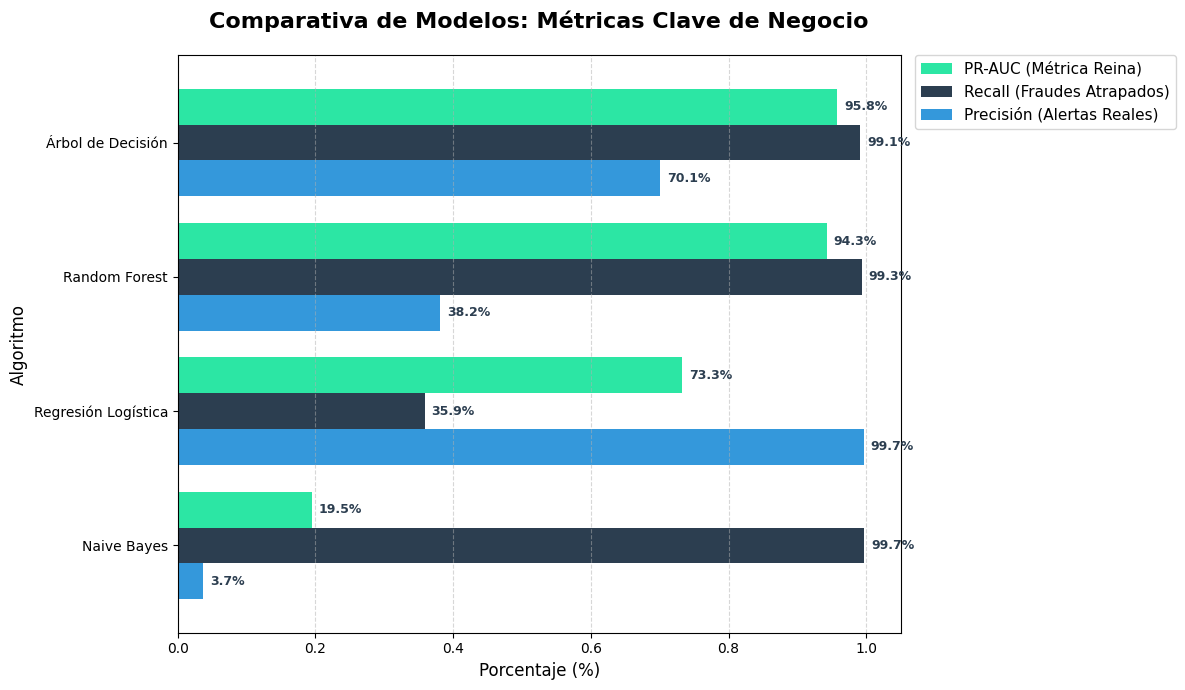

,PR-AUC (Métrica Reina),Recall (Fraudes Atrapados),Precisión (Alertas Reales),Especificidad (Clientes a Salvo),F1-Score (Balance)
Modelo,,,,,
Árbol de Decisión,95.81%,99.13%,70.08%,99.33%,82.11%
Random Forest,94.30%,99.32%,38.16%,97.45%,55.13%
Regresión Logística,73.29%,35.87%,99.66%,100.00%,52.76%
Naive Bayes,19.51%,99.69%,3.71%,59.03%,7.15%


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

datos_modelos = {
    "Modelo": [
        "Random Forest",
        "Árbol de Decisión",
        "Regresión Logística",
        "Naive Bayes"
    ],
    "PR-AUC (Métrica Reina)": [
        pr_auc_rf,
        pr_auc_dt,
        pr_auc_lr,
        pr_auc_NB
    ],
    "Recall (Fraudes Atrapados)": [
        recall_rf,
        recall_dt,
        recall_lr,
        recall_NB
    ],
    "Precisión (Alertas Reales)": [
        precision_rf,
        precision_dt,
        precision_lr,
        precision_NB
    ],
    "Especificidad (Clientes a Salvo)": [
        especificidad_rf,
        especificidad_dt,
        especificidad_lr,
        especificidad_NB
    ],
    "F1-Score (Balance)": [
        f1_rf,
        f1_dt,
        f1_lr,
        f1_NB
    ]
}

df_resultados = pd.DataFrame(datos_modelos)
df_resultados.set_index("Modelo", inplace=True)
df_resultados.sort_values(by="PR-AUC (Métrica Reina)", ascending=False, inplace=True)

df_grafico = df_resultados[["PR-AUC (Métrica Reina)", "Recall (Fraudes Atrapados)", "Precisión (Alertas Reales)"]]
ax = df_grafico.plot(kind="barh", figsize=(12, 7), width=0.8, color=["#2ce6a4", "#2c3e50", "#3498db"])
plt.title("Comparativa de Modelos: Métricas Clave de Negocio", fontsize=16, pad=20, weight="bold")
plt.xlabel("Porcentaje (%)", fontsize=12)
plt.ylabel("Algoritmo", fontsize=12)
plt.xlim(0, 1.05)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=11)

for p in ax.patches:
    width = p.get_width()
    if width > 0.01:
        ax.text(width + 0.01, p.get_y() + p.get_height()/2, f'{width:.1%}', 
                va="center", ha="left", fontsize=9, color="#2c3e50", weight="bold")

plt.tight_layout()
plt.show()

tabla_estilizada = (
    df_resultados.style
    .format("{:.2%}")
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1, subset=df_resultados.columns)
    .set_caption("PANEL DE CONTROL EJECUTIVO: EVALUACIÓN DE MODELOS")
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '18px'), ('font-weight', 'bold'), ('text-align', 'center'), ('margin-bottom', '15px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '13px'), ('text-align', 'center'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('font-size', '13px'), ('text-align', 'center'), ('padding', '10px'), ('border', '1px solid #ffffff')]},
        {'selector': 'th.row_heading', 'props': [('background-color', '#f8f9fa'), ('color', '#2c3e50'), ('text-align', 'left'), ('font-weight', 'bold')]}
    ])
)

tabla_estilizada

## 10. Optimización y Refinamiento de Hiperparámetros

Con base en el análisis del panel de control ejecutivo, iniciamos la fase de optimización con el objetivo de resolver los cuellos de botella operativos detectados en la fase de experimentación.

Debido a las severas restricciones computacionales que impone el procesamiento de un dataset masivo de 6.3 millones de registros, implementamos una estrategia de **Búsqueda Aleatoria Quirúrgica** (`RandomizedSearchCV`) ejecutada de forma estrictamente secuencial (`n_jobs=1`).

Esta configuración, sumada a la recolección forzada de basura en memoria (`gc.collect()`), nos permite explorar configuraciones avanzadas de los modelos sin comprometer la estabilidad del kernel ni saturar la memoria RAM.

### 10.1. Árbol de Decisión Optimizado

🧹 Liberando memoria RAM residual...
⏳ Iniciando refinamiento avanzado para Árbol de Decisión...
🏋️ Entrenando búsqueda refinada de forma secuencial...
✅ Búsqueda concluida. Mejores parámetros refinados: {'min_samples_split': 30, 'min_samples_leaf': 20, 'max_depth': 12, 'criterion': 'gini'}
🔮 Generando predicciones en el set de Test...
📊 Calculando métricas de validación...
------------------------------------------------------------

🏆 === REPORTE: ÁRBOL DE DECISIÓN REFINADO ===
🥇 MÉTRICA REINA (PR-AUC):         0.9702
🎯 RECALL (Fraudes Atrapados):     0.9839 -> (98.39% del total real)
🛡️ ESPECIFICIDAD (Falsas Alarmas): 0.9969 -> (Bloqueó al 0.31% de clientes buenos)
⚖️ F1-SCORE (Balance General):     0.9033
📈 PRECISIÓN (Efectividad Alerta): 0.8349
------------------------------------------------------------

📋 INFORME DETALLADO DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00    101973
      Fraude       0.83      0.9

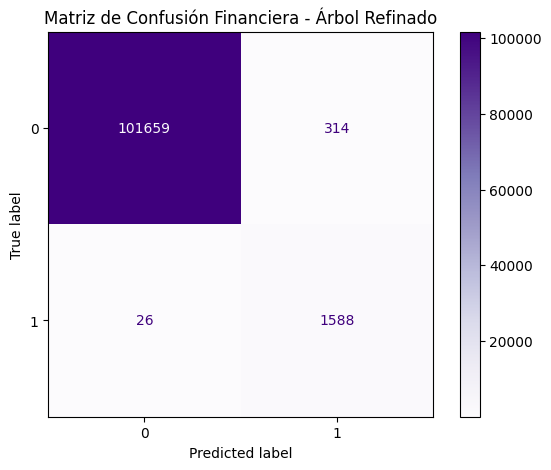

In [26]:
import gc
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (ConfusionMatrixDisplay,classification_report,average_precision_score,recall_score,precision_score,f1_score)

print("🧹 Liberando memoria RAM residual...")
gc.collect()

print("⏳ Iniciando refinamiento avanzado para Árbol de Decisión...")

espacio_parametros_dt = {
    'max_depth': [10, 11, 12],
    'min_samples_split': [30, 50, 70],
    'min_samples_leaf': [15, 20, 30],
    'criterion': ['gini']
}

modelo_base_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

busqueda_dt = RandomizedSearchCV(
    estimator=modelo_base_dt,
    param_distributions=espacio_parametros_dt,
    n_iter=4,
    scoring='average_precision',
    cv=2,
    random_state=42,
    n_jobs=1
)

print("🏋️ Entrenando búsqueda refinada de forma secuencial...")
busqueda_dt.fit(X_train, y_train)

print(f"✅ Búsqueda concluida. Mejores parámetros refinados: {busqueda_dt.best_params_}")
modelo_optimo_dt = busqueda_dt.best_estimator_

print("🔮 Generando predicciones en el set de Test...")
predicciones_opt_dt = modelo_optimo_dt.predict(X_test)
probabilidades_opt_dt = modelo_optimo_dt.predict_proba(X_test)[:, 1]

print("📊 Calculando métricas de validación...")
print("-" * 60)

precision_opt_dt = precision_score(y_test, predicciones_opt_dt)
recall_opt_dt = recall_score(y_test, predicciones_opt_dt)
f1_opt_dt = f1_score(y_test, predicciones_opt_dt)
pr_auc_opt_dt = average_precision_score(y_test, probabilidades_opt_dt)
especificidad_opt_dt = recall_score(y_test, predicciones_opt_dt, pos_label=0)

print("\n🏆 === REPORTE: ÁRBOL DE DECISIÓN REFINADO ===")
print(f"🥇 MÉTRICA REINA (PR-AUC):         {pr_auc_opt_dt:.4f}")
print(f"🎯 RECALL (Fraudes Atrapados):     {recall_opt_dt:.4f} -> ({round(recall_opt_dt*100,2)}% del total real)")
print(f"🛡️ ESPECIFICIDAD (Falsas Alarmas): {especificidad_opt_dt:.4f} -> (Bloqueó al {round((1-especificidad_opt_dt)*100,2)}% de clientes buenos)")
print(f"⚖️ F1-SCORE (Balance General):     {f1_opt_dt:.4f}")
print(f"📈 PRECISIÓN (Efectividad Alerta): {precision_opt_dt:.4f}")
print("-" * 60)

print("\n📋 INFORME DETALLADO DE CLASIFICACIÓN:")
print(classification_report(y_test, predicciones_opt_dt, target_names=['Legítimo', 'Fraude']))
print("-" * 60)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    predicciones_opt_dt, 
    ax=ax, 
    cmap='Purples', 
    values_format='d'
)
plt.title('Matriz de Confusión Financiera - Árbol Refinado')
plt.grid(False)
plt.show()

### 10.2. Random Forest Optimizado

🧹 Liberando memoria RAM residual...
⏳ Iniciando optimización segura para Random Forest...
🏋️ Buscando hiperparámetros en el bosque de forma secuencial (Protección de RAM)...
✅ Búsqueda concluida. Mejores parámetros encontrados: {'n_estimators': 40, 'min_samples_split': 30, 'min_samples_leaf': 20, 'max_depth': 14}
🔮 Generando predicciones en el set de Test...
📊 Calculando métricas de validación...
------------------------------------------------------------

🏆 === REPORTE: RANDOM FOREST OPTIMIZADO ===
🥇 MÉTRICA REINA (PR-AUC):         0.9654
🎯 RECALL (Fraudes Atrapados):     0.9919 -> (99.19% del total real)
🛡️ ESPECIFICIDAD (Falsas Alarmas): 0.9855 -> (Bloqueó al 1.45% de clientes buenos)
⚖️ F1-SCORE (Balance General):     0.6823
📈 PRECISIÓN (Efectividad Alerta): 0.5200
------------------------------------------------------------

📋 INFORME DETALLADO DE CLASIFICACIÓN:
              precision    recall  f1-score   support

    Legítimo       1.00      0.99      0.99    101973
      Frau

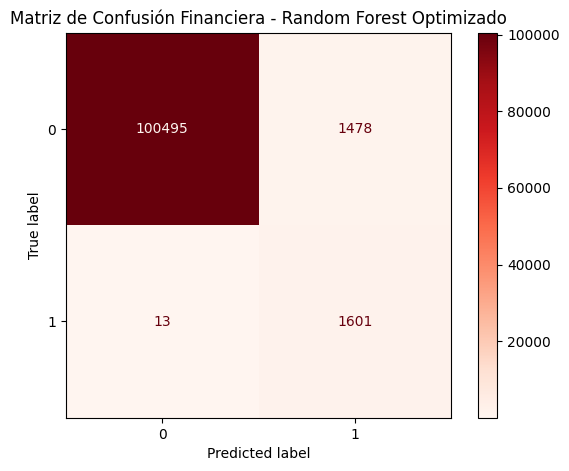

In [27]:
import gc
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score
)

print("🧹 Liberando memoria RAM residual...")
gc.collect()

print("⏳ Iniciando optimización segura para Random Forest...")

espacio_parametros_rf = {
    'n_estimators': [40, 50],
    'max_depth': [10, 12, 14],
    'min_samples_split': [30, 50],
    'min_samples_leaf': [20, 30]
}

modelo_base_rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1)

busqueda_rf = RandomizedSearchCV(
    estimator=modelo_base_rf,
    param_distributions=espacio_parametros_rf,
    n_iter=3,
    scoring='average_precision',
    cv=2,
    random_state=42,
    n_jobs=1
)

print("🏋️ Buscando hiperparámetros en el bosque de forma secuencial (Protección de RAM)...")
busqueda_rf.fit(X_train, y_train)

print(f"✅ Búsqueda concluida. Mejores parámetros encontrados: {busqueda_rf.best_params_}")
modelo_optimo_rf = busqueda_rf.best_estimator_

print("🔮 Generando predicciones en el set de Test...")
predicciones_opt_rf = modelo_optimo_rf.predict(X_test)
probabilidades_opt_rf = modelo_optimo_rf.predict_proba(X_test)[:, 1]

print("📊 Calculando métricas de validación...")
print("-" * 60)

precision_opt_rf = precision_score(y_test, predicciones_opt_rf)
recall_opt_rf = recall_score(y_test, predicciones_opt_rf)
f1_opt_rf = f1_score(y_test, predicciones_opt_rf)
pr_auc_opt_rf = average_precision_score(y_test, probabilidades_opt_rf)
especificidad_opt_rf = recall_score(y_test, predicciones_opt_rf, pos_label=0)

print("\n🏆 === REPORTE: RANDOM FOREST OPTIMIZADO ===")
print(f"🥇 MÉTRICA REINA (PR-AUC):         {pr_auc_opt_rf:.4f}")
print(f"🎯 RECALL (Fraudes Atrapados):     {recall_opt_rf:.4f} -> ({round(recall_opt_rf*100,2)}% del total real)")
print(f"🛡️ ESPECIFICIDAD (Falsas Alarmas): {especificidad_opt_rf:.4f} -> (Bloqueó al {round((1-especificidad_opt_rf)*100,2)}% de clientes buenos)")
print(f"⚖️ F1-SCORE (Balance General):     {f1_opt_rf:.4f}")
print(f"📈 PRECISIÓN (Efectividad Alerta): {precision_opt_rf:.4f}")
print("-" * 60)

print("\n📋 INFORME DETALLADO DE CLASIFICACIÓN:")
print(classification_report(y_test, predicciones_opt_rf, target_names=['Legítimo', 'Fraude']))
print("-" * 60)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    predicciones_opt_rf, 
    ax=ax, 
    cmap='Reds', 
    values_format='d'
)
plt.title('Matriz de Confusión Financiera - Random Forest Optimizado')
plt.grid(False)
plt.show()

## 11. Almacenamiento y prueba del modelo definitivo

In [28]:
import os
import joblib

ruta_modelos = '../models/'
nombre_archivo_dt = os.path.join(ruta_modelos, 'modelo_arbol_optimizado_v2.pkl')

os.makedirs(ruta_modelos, exist_ok=True)

print(f"💾 Guardando el Árbol de Decisión Optimizado en '{nombre_archivo_dt}'...")
joblib.dump(modelo_optimo_dt, nombre_archivo_dt)
print("✅ Archivo serializado correctamente.")

💾 Guardando el Árbol de Decisión Optimizado en '../models/modelo_arbol_optimizado_v2.pkl'...
✅ Archivo serializado correctamente.


### 11.1. Prueba de Carga y Validación de Consistencia

Para asegurar que el proceso de exportación no corrompió la estructura del modelo y garantizar que el archivo guardado reproduce exactamente los mismos resultados, procedemos a realizar una **prueba de carga en frío**.

Cargaremos el archivo `.pkl` desde el directorio `../models/` y volveremos a evaluar las métricas clave sobre el conjunto de test (`X_test`), contrastándolas con las obtenidas antes del almacenamiento.

El objetivo es validar que la consistencia del modelo se mantenga al **100%**, confirmando la integridad del proceso de serialización y deserialización.

In [29]:
import os
import joblib
from sklearn.metrics import average_precision_score, recall_score, precision_score

ruta_modelos = '../models/'
nombre_archivo_dt = os.path.join(ruta_modelos, 'modelo_arbol_optimizado_v2.pkl')

print("🔄 Cargando el modelo final desde el almacenamiento...")
modelo_recuperado_dt = joblib.load(nombre_archivo_dt)
print("✅ Modelo cargado correctamente.")
print("-" * 60)

print("🔮 Ejecutando predicciones de prueba con el modelo recuperado...")
predicciones_test = modelo_recuperado_dt.predict(X_test)
probabilidades_test = modelo_recuperado_dt.predict_proba(X_test)[:, 1]

precision_control = precision_score(y_test, predicciones_test)
recall_control = recall_score(y_test, predicciones_test)
pr_auc_control = average_precision_score(y_test, probabilidades_test)

print("\n📊 === TABLA DE VERIFICACIÓN DE INTEGRIDAD ===")
print(f"🔹 PR-AUC Esperado:  0.9702  |  PR-AUC Obtenido:  {pr_auc_control:.4f}")
print(f"🔹 Recall Esperado:  0.9839  |  Recall Obtenido:  {recall_control:.4f}")
print(f"🔹 Precisión Esperada: 0.8349 |  Precisión Obtenida: {precision_control:.4f}")
print("-" * 60)

cuadra_pr_auc = round(pr_auc_control, 4) == 0.9702
cuadra_recall = round(recall_control, 4) == 0.9839
cuadra_precision = round(precision_control, 4) == 0.8349

if cuadra_pr_auc and cuadra_recall and cuadra_precision:
    print("🎉 ¡TODO CUADRA PERFECTAMENTE! El modelo recuperado es 100% idéntico al original.")
    print("   El sistema está listo para ser integrado en el pipeline de producción.")
else:
    print("⚠️ ADVERTENCIA: Se detectó una discrepancia en las métricas.")
    print("   Por favor, verifica que estás evaluando exactamente el mismo set de datos (X_test, y_test).")

🔄 Cargando el modelo final desde el almacenamiento...
✅ Modelo cargado correctamente.
------------------------------------------------------------
🔮 Ejecutando predicciones de prueba con el modelo recuperado...

📊 === TABLA DE VERIFICACIÓN DE INTEGRIDAD ===
🔹 PR-AUC Esperado:  0.9702  |  PR-AUC Obtenido:  0.9702
🔹 Recall Esperado:  0.9839  |  Recall Obtenido:  0.9839
🔹 Precisión Esperada: 0.8349 |  Precisión Obtenida: 0.8349
------------------------------------------------------------
🎉 ¡TODO CUADRA PERFECTAMENTE! El modelo recuperado es 100% idéntico al original.
   El sistema está listo para ser integrado en el pipeline de producción.
